In [1]:
RANDOM_STATE = 42

from pathlib import Path
import sys

BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

sys.path.insert(0, str(BASE_DIR))

# 01 — Análise Exploratória de Dados

## Contexto e objetivo

A avaliação da qualidade do vinho tradicionalmente envolve análise sensorial especializada. Neste projeto, buscamos verificar se medições físico-químicas podem fornecer sinal suficiente para apoiar a identificação de vinhos classificados como **High Quality**.

A análise exploratória tem três objetivos: compreender a estrutura da base, identificar limitações de qualidade dos dados e encontrar padrões que orientem as etapas de preparação e modelagem.

O foco desta etapa é descritivo e analítico. Relações estatísticas são tratadas como associações e não como evidência de causalidade.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import DATA_FILE, FIGURES_DIR, METRICS_DIR
from src.data import load_dataset
from src.preprocessing import create_target, get_features, outlier_report

df = create_target(load_dataset(DATA_FILE))
features = get_features(df)

print(f"Dataset dimensions: {df.shape}")
display(df.head())
display(df.dtypes.to_frame("Data type"))

Dataset dimensions: (1143, 14)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,high_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,0


,Data type
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


## 1. Qualidade e estrutura dos dados

A base possui 1.143 observações e 13 colunas originais. A coluna `quality` representa a avaliação de qualidade e `Id` é tratado apenas como identificador, não participando da modelagem.

In [3]:
quality_report = pd.DataFrame({
    "Missing count": df.isna().sum(),
    "Missing percentage": (df.isna().mean() * 100).round(2),
})

print("Total missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
display(quality_report)

Total missing values: 0
Duplicate rows: 0


,Missing count,Missing percentage
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


### Interpretação

Não foram identificados valores ausentes nem registros duplicados. Valores iguais a zero são analisados separadamente, pois o valor zero pode ser válido para determinadas medições e não deve ser tratado automaticamente como ausência.

In [4]:
zero_table = pd.DataFrame({
    "Zero count": (df == 0).sum(),
    "Zero percentage": ((df == 0).mean() * 100).round(2),
})
display(zero_table[zero_table["Zero count"] > 0].sort_values("Zero count", ascending=False))

,Zero count,Zero percentage
high_quality,984,86.09
citric acid,99,8.66
Id,1,0.09


## 2. Definição da variável alvo e balanceamento

O score original de qualidade é transformado em uma classificação binária:

- `quality >= 7` → **High Quality (1)**
- `quality < 7` → **Low/Medium Quality (0)**

O limiar de 7 segue a formulação definida no Tech Challenge e permite transformar a nota ordinal em uma decisão binária de triagem de qualidade.

/mnt/data/tc02_final/notebooks/01_eda.ipynb:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  },


,Count,Percentage
Low/Medium Quality,984,86.09
High Quality,159,13.91


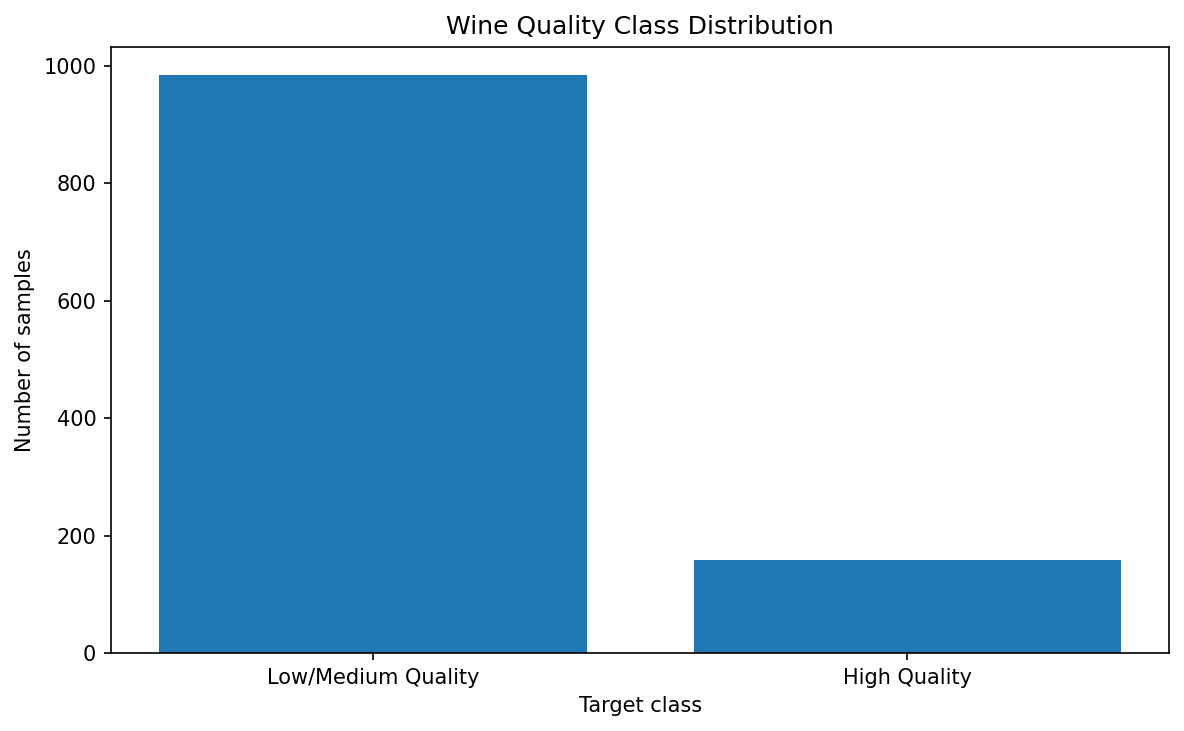

In [5]:
target_table = df["high_quality"].value_counts().sort_index().to_frame("Count")
target_table["Percentage"] = (target_table["Count"] / len(df) * 100).round(2)
target_table.index = ["Low/Medium Quality", "High Quality"]
display(target_table)

plt.figure(figsize=(8,5))
plt.bar([0,1], target_table["Count"].values)
plt.title("Wine Quality Class Distribution")
plt.xlabel("Target class")
plt.ylabel("Number of samples")
plt.xticks([0,1],["Low/Medium Quality","High Quality"])
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação

A classe **High Quality representa 13,91%** da base, enquanto **Low/Medium Quality representa 86,09%**. Existe, portanto, desbalanceamento relevante. Esse resultado será considerado na seleção das métricas, evitando que Accuracy seja usada isoladamente.

## 3. Distribuições das variáveis físico-químicas

As distribuições ajudam a identificar diferenças de escala, assimetria e caudas longas. Esse diagnóstico é relevante para decidir quando a padronização é necessária e para compreender o comportamento dos dados antes da modelagem.

/mnt/data/tc02_final/notebooks/01_eda.ipynb:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  }


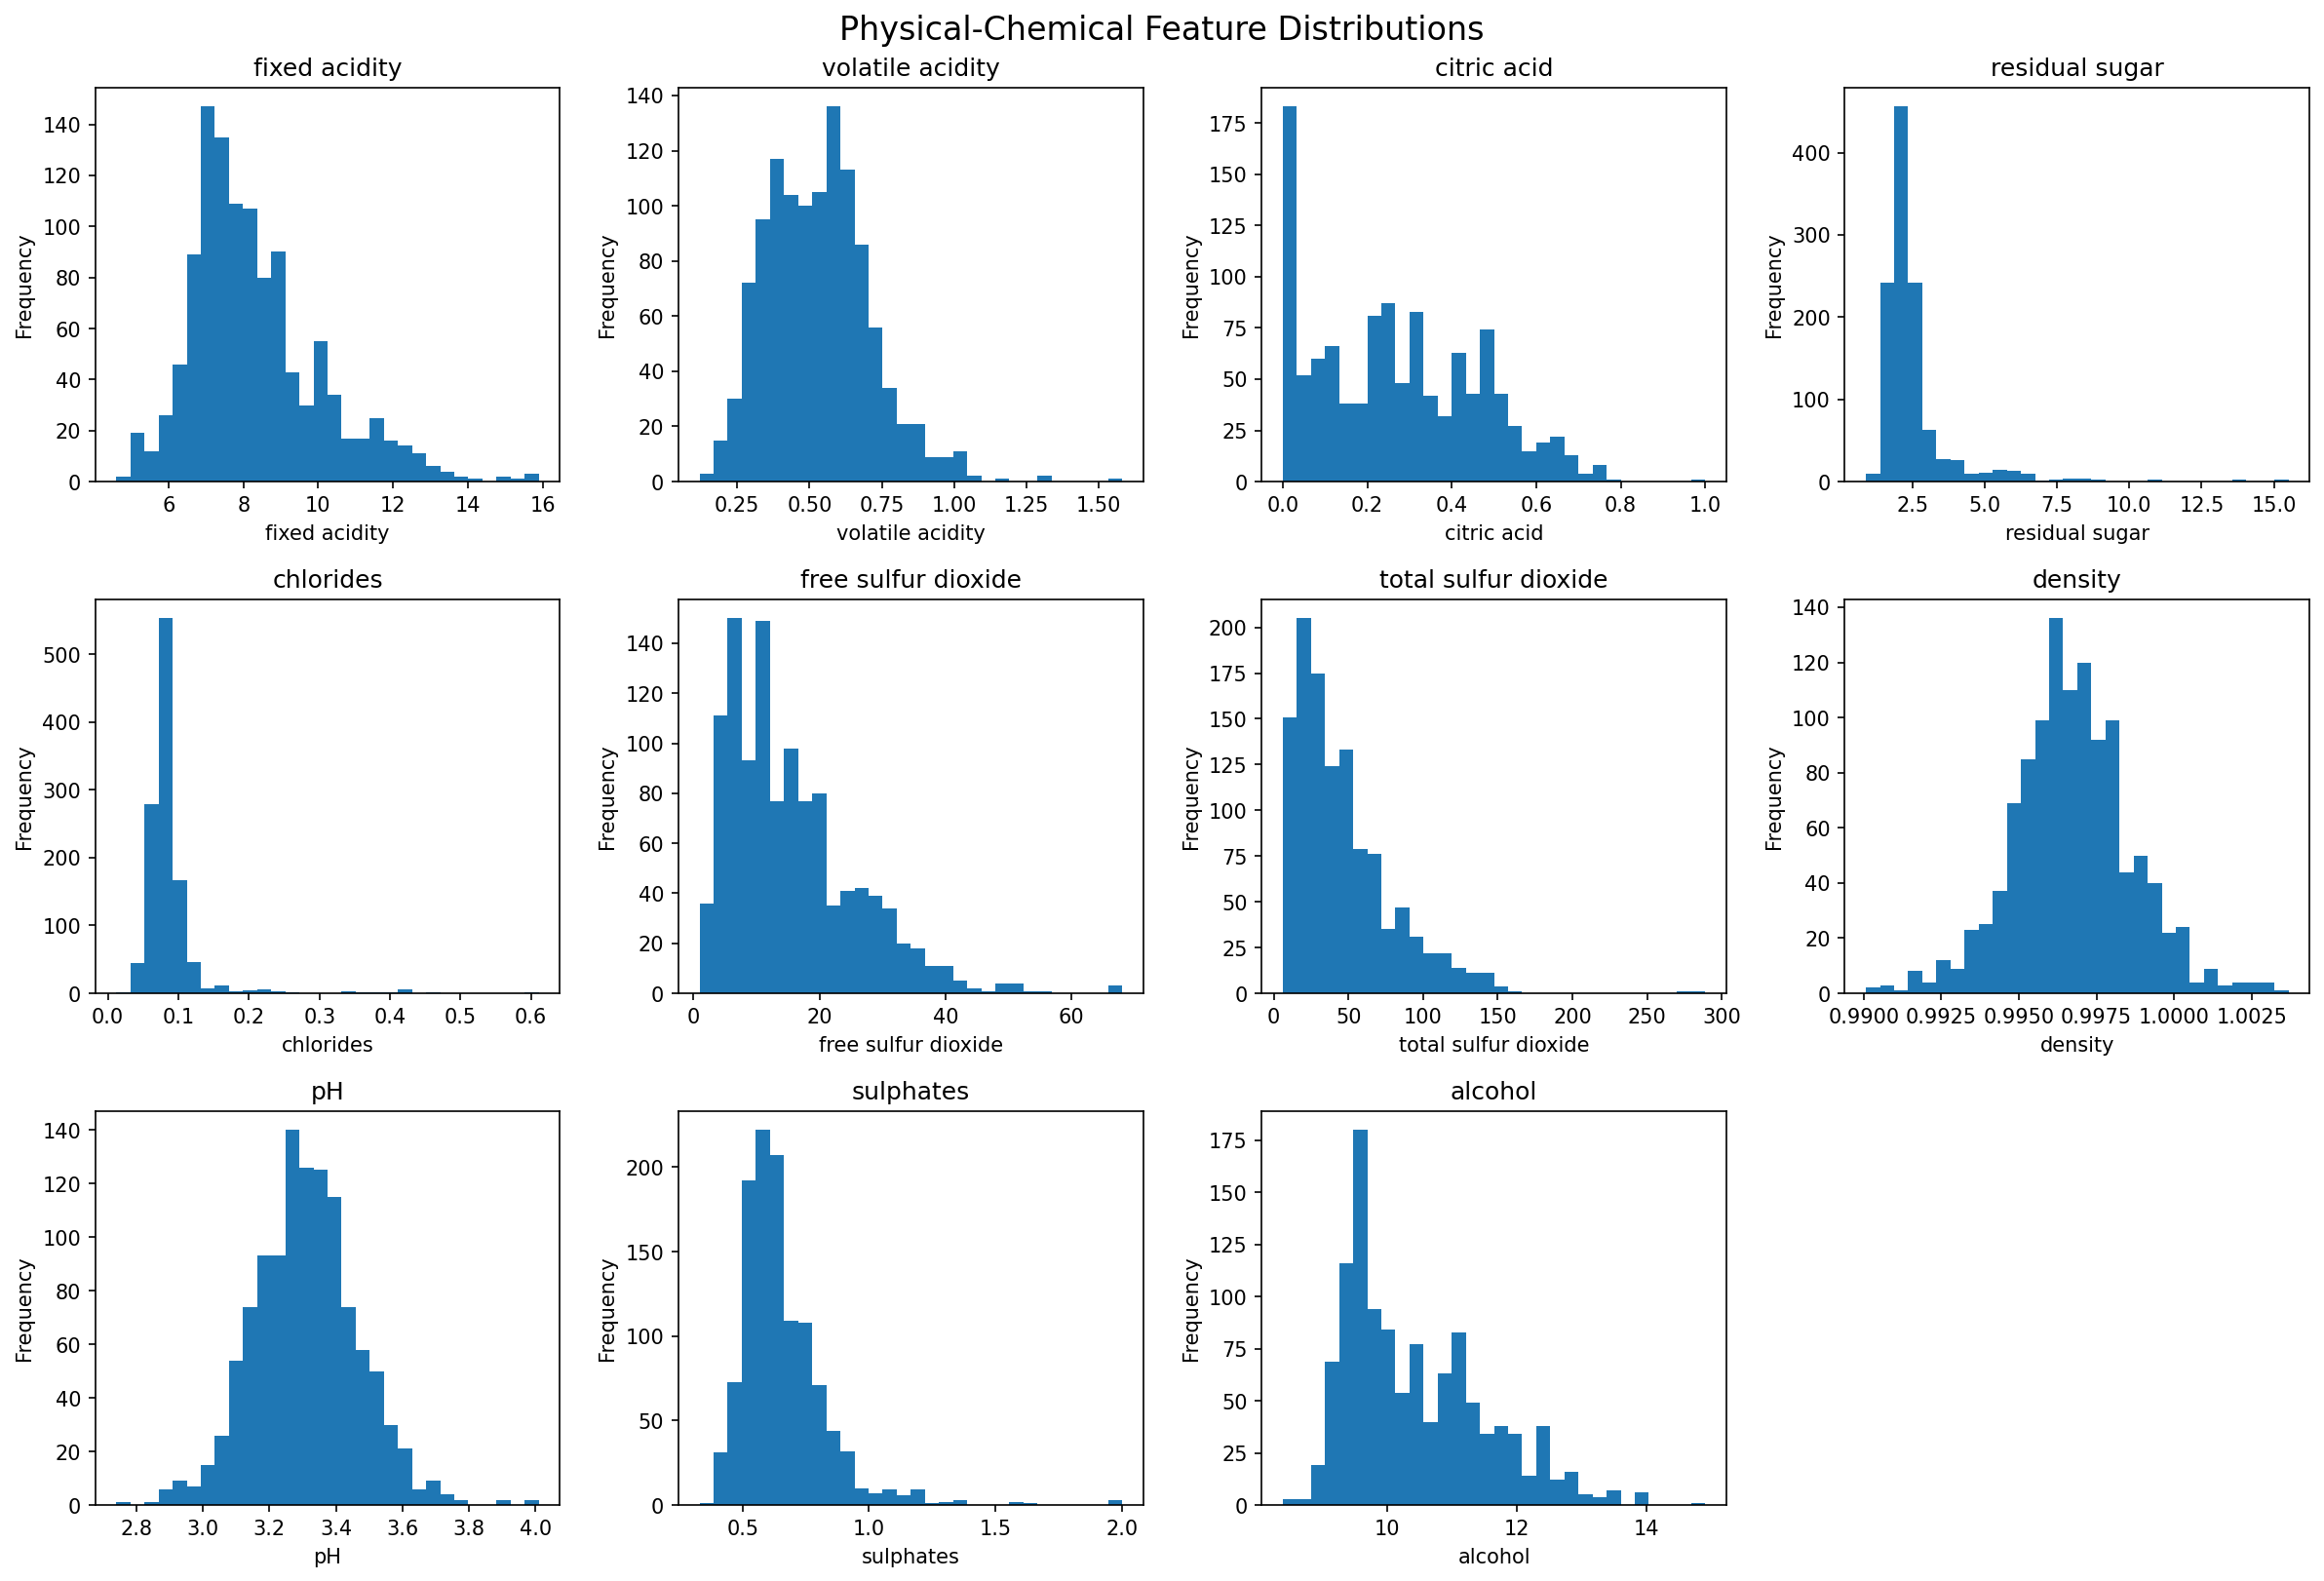

In [6]:
fig, axes = plt.subplots(3,4,figsize=(16,11))
axes = axes.flatten()
for ax, col in zip(axes, features):
    ax.hist(df[col], bins=30)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
for ax in axes[len(features):]:
    ax.axis("off")
fig.suptitle("Physical-Chemical Feature Distributions", fontsize=16)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação

As variáveis apresentam escalas e formatos diferentes. `residual sugar`, `free sulfur dioxide` e `total sulfur dioxide` apresentam caudas mais longas, enquanto algumas características permanecem mais concentradas em intervalos estreitos. Essa heterogeneidade é importante para a preparação dos modelos.

## 4. Correlações

A correlação de Pearson é utilizada como medida descritiva de associação linear entre as variáveis. O objetivo é identificar relações que mereçam investigação adicional e não estabelecer causalidade.

/mnt/data/tc02_final/notebooks/01_eda.ipynb:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  "source": [
/mnt/data/tc02_final/notebooks/01_eda.ipynb:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  "sys.path.insert(0, str(BASE_DIR))"


,Pearson correlation with quality
high_quality,0.720433
alcohol,0.484866
volatile acidity,-0.407394
sulphates,0.257710
citric acid,0.240821
total sulfur dioxide,-0.183339
density,-0.175208
chlorides,-0.124085
fixed acidity,0.121970
free sulfur dioxide,-0.063260


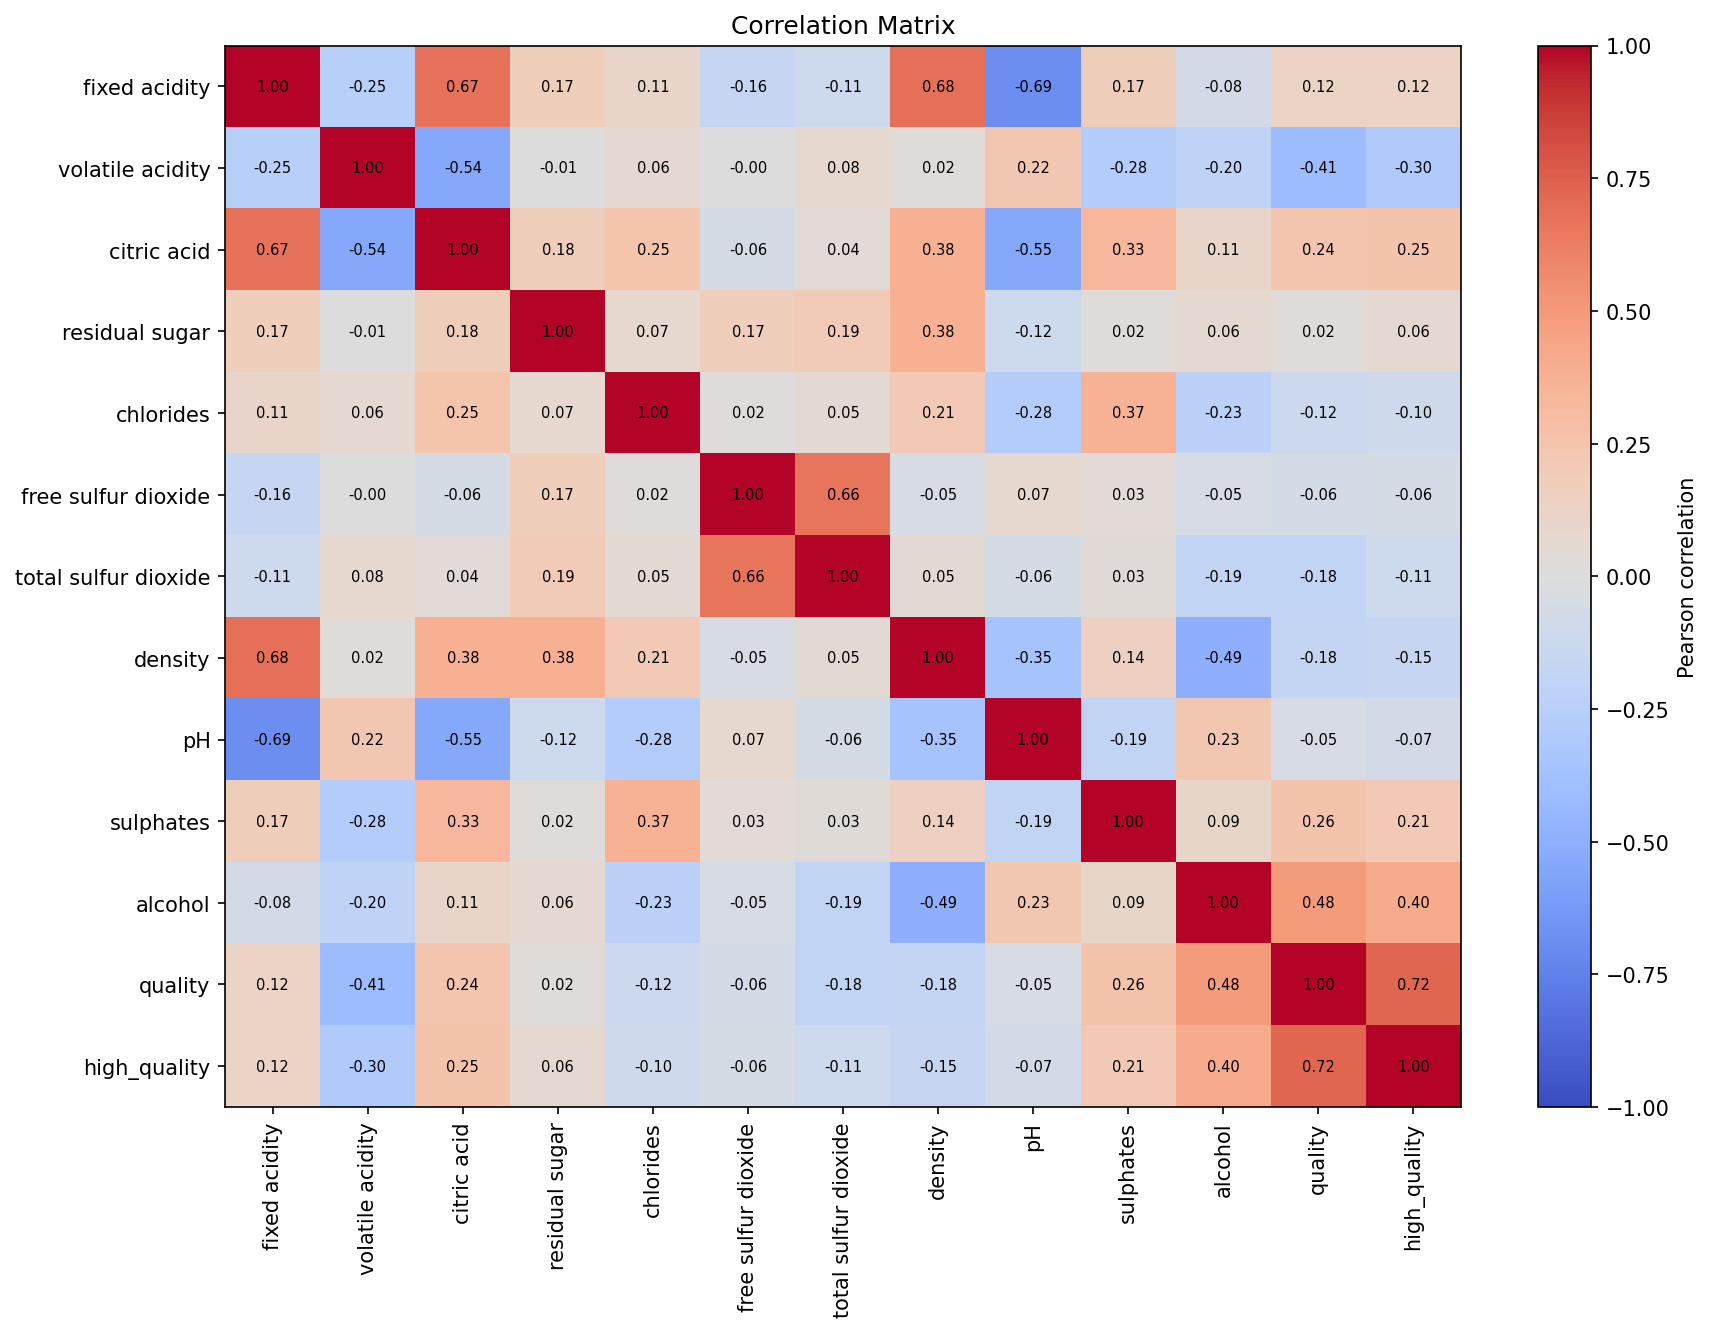

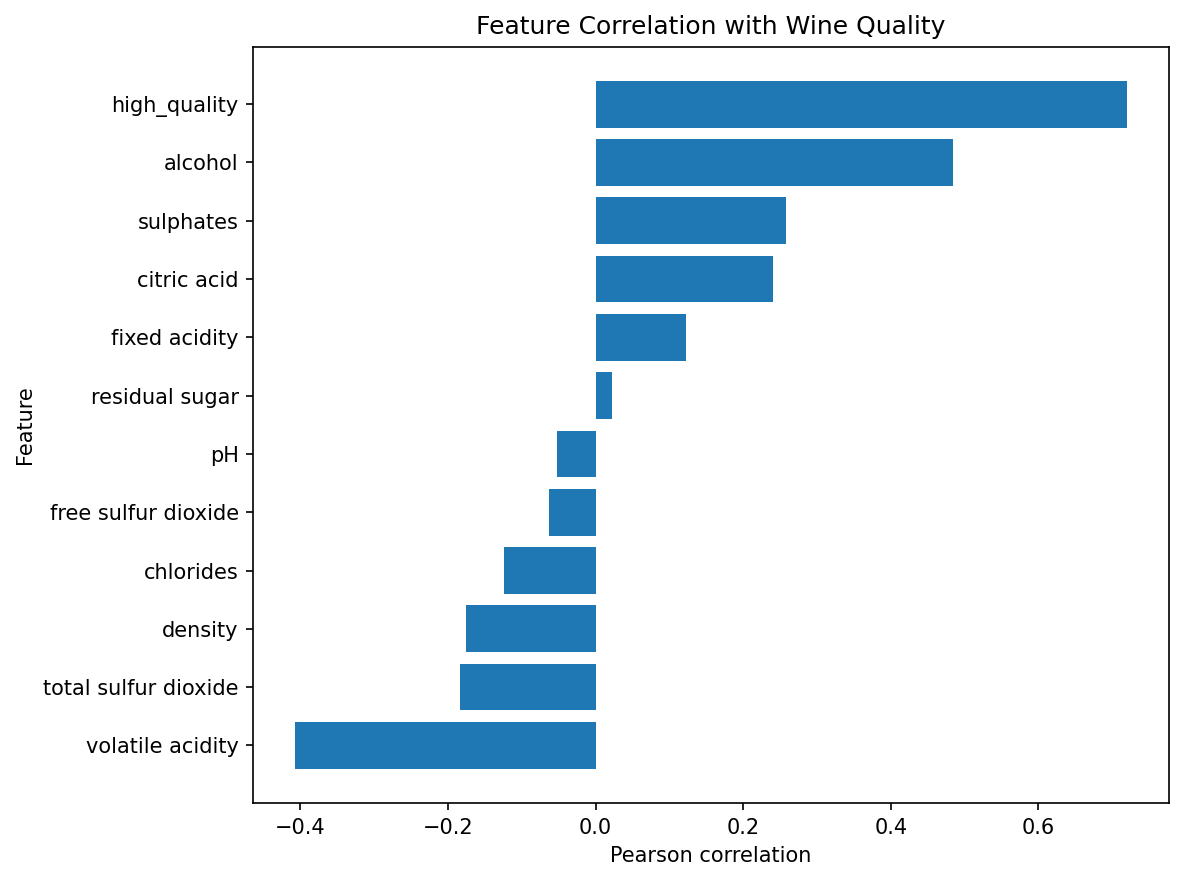

In [7]:
corr = df.drop(columns=["Id"], errors="ignore").corr(numeric_only=True)
quality_corr = corr["quality"].drop("quality").sort_values(key=abs, ascending=False)
display(quality_corr.to_frame("Pearson correlation with quality"))

plt.figure(figsize=(12,9))
im = plt.imshow(corr, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(im, label="Pearson correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,6))
qplot = quality_corr.sort_values()
plt.barh(qplot.index, qplot.values)
plt.title("Feature Correlation with Wine Quality")
plt.xlabel("Pearson correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_quality_correlations.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação

Entre as maiores associações lineares com `quality`, destacam-se `alcohol` de forma positiva e `volatile acidity` de forma negativa. `sulphates` e `citric acid` também apresentam associações positivas. Esses resultados serão confrontados posteriormente com a importância das variáveis calculada diretamente a partir do modelo.

## 5. Outliers

A regra do intervalo interquartil (IQR) é utilizada para sinalizar observações estatisticamente extremas. A presença de um outlier não implica, por si só, erro de medição ou registro.

/mnt/data/tc02_final/notebooks/01_eda.ipynb:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  "shell.execute_reply": "2026-09-01T00:08:18.150808Z"


,Feature,Q1,Q3,IQR,Lower bound,Upper bound,Outliers,Outlier percentage
0,residual sugar,1.90000,2.600000,0.700000,0.850000,3.650000,110,9.62
1,chlorides,0.07000,0.090000,0.020000,0.040000,0.120000,77,6.74
2,fixed acidity,7.10000,9.100000,2.000000,4.100000,12.100000,44,3.85
3,sulphates,0.55000,0.730000,0.180000,0.280000,1.000000,43,3.76
4,total sulfur dioxide,21.00000,61.000000,40.000000,-39.000000,121.000000,40,3.50
5,density,0.99557,0.997845,0.002275,0.992157,1.001257,36,3.15
6,pH,3.20500,3.400000,0.195000,2.912500,3.692500,20,1.75
7,free sulfur dioxide,7.00000,21.000000,14.000000,-14.000000,42.000000,18,1.57
8,volatile acidity,0.39250,0.640000,0.247500,0.021250,1.011250,14,1.22
9,alcohol,9.50000,11.100000,1.600000,7.100000,13.500000,12,1.05


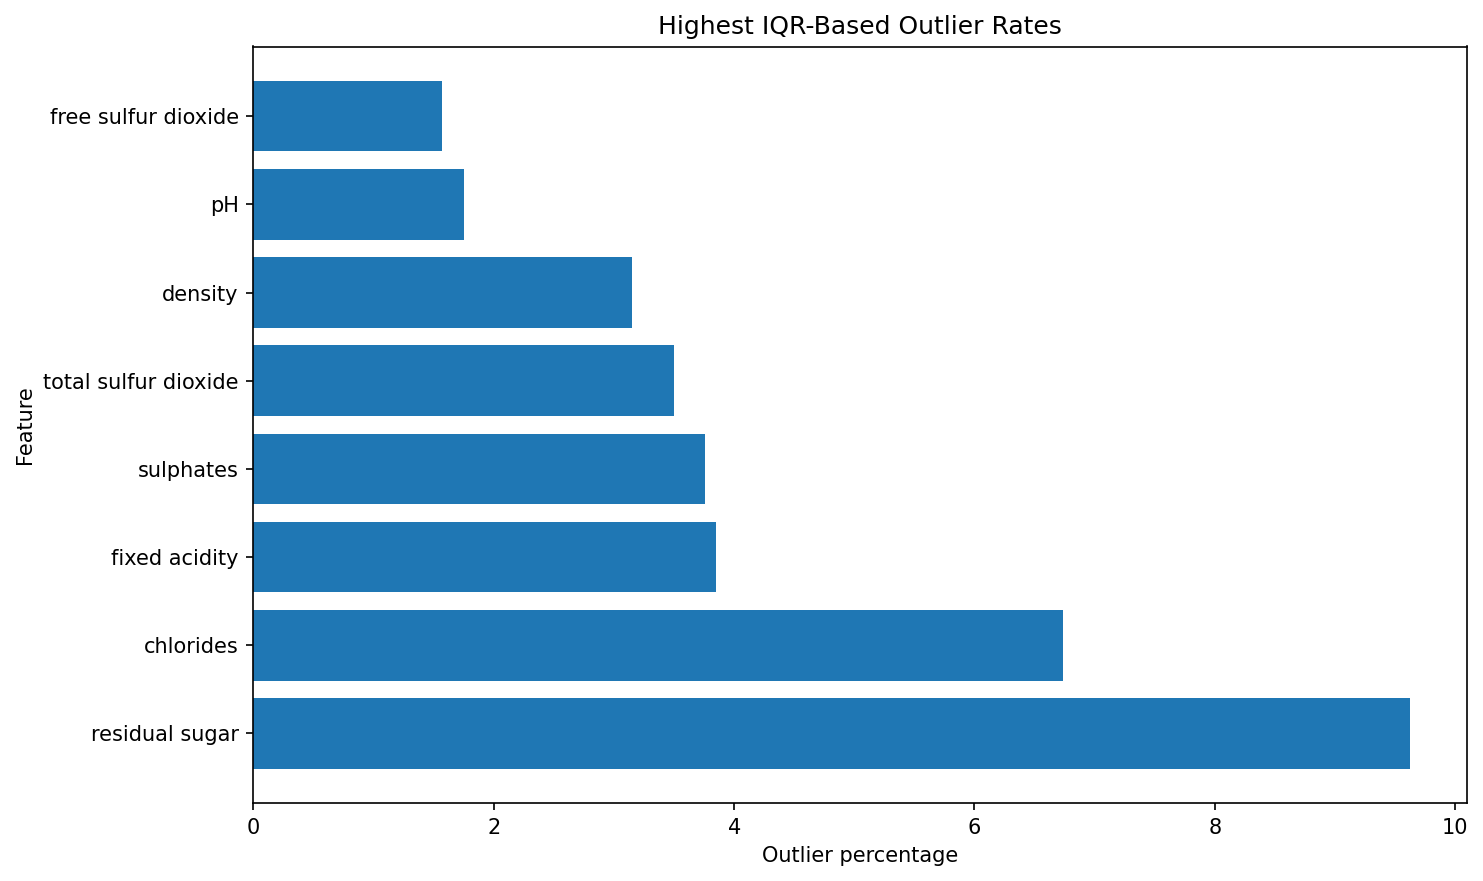

In [8]:
outliers = outlier_report(df, features)
display(outliers)
outliers.to_csv(METRICS_DIR / "outlier_summary.csv", index=False)

plt.figure(figsize=(10,6))
plt.barh(outliers.head(8)["Feature"], outliers.head(8)["Outlier percentage"])
plt.title("Highest IQR-Based Outlier Rates")
plt.xlabel("Outlier percentage")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_outliers.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação

Os maiores percentuais de outliers concentram-se em `residual sugar` e `chlorides`. As observações foram mantidas porque o critério IQR identifica extremos estatísticos, mas não fornece evidência suficiente para classificá-los como erros. A remoção indiscriminada poderia retirar sinal útil do problema de classificação.